In [27]:
!pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable


In [44]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, het_white, linear_reset
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

df = pd.read_csv("dados/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [15]:
df = pd.read_csv('dados/insurance.csv')
df.head



<bound method NDFrame.head of       age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]>

In [46]:
#número de observações
print(f"Número de observações: {df.shape[0]}")
print(f"Número de variáveis: {df.shape[1]}")
df.columns

Número de observações: 1338
Número de variáveis: 7


Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

#### Análise descritiva da base de dados contendo:

In [ ]:
# medidas de tendência central: 
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [19]:
# assimetria:
df.select_dtypes(include='number').skew()

age         0.055673
bmi         0.284047
children    0.938380
charges     1.515880
dtype: float64

In [20]:
# curtose:
df.select_dtypes(include='number').kurtosis()

age        -1.245088
bmi        -0.050732
children    0.202454
charges     1.606299
dtype: float64

In [21]:
#  coeficiente de variação:
cv = df.select_dtypes(include='number').std()/df.select_dtypes(include='number').mean()*100
print(cv)

age          35.835313
bmi          19.887513
children    110.098927
charges      91.255659
dtype: float64


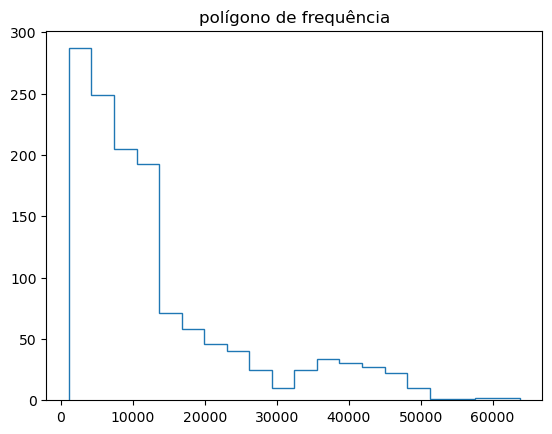

In [26]:
# polígono de frequência:

plt.hist(df['charges'],
        bins=20,
        histtype='step')

plt.title("polígono de frequência")
plt.show()



#### Estimação do modelo de regressão múltipla:

In [ ]:
# verificando que as três colunas são strings 
print(df.dtypes)

print(df['sex'].unique())
print(df['smoker'].unique())
print(df['region'].unique())

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object
<ArrowStringArray>
['female', 'male']
Length: 2, dtype: str
<ArrowStringArray>
['yes', 'no']
Length: 2, dtype: str
<ArrowStringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str


In [38]:
# vamos trç  
import statsmodels.formula.api as smf

modelo = smf.ols(
    'charges ~ age + bmi + children + sex + smoker + region',
     data=df
                 ).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.8
Date:                qua, 08 jul 2026   Prob (F-statistic):               0.00
Time:                        17:08:20   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept           -1.194e+04    

# Análise dos Resultados da Regressão Múltipla

## Qualidade do Ajuste do Modelo

O modelo estimado apresentou coeficiente de determinação (R²) igual a **0,751**, indicando que aproximadamente **75,1% da variação dos gastos médicos (charges)** é explicada pelas variáveis incluídas na regressão. O **R² ajustado foi de 0,749**, valor muito próximo ao R², sugerindo que as variáveis explicativas contribuem efetivamente para o poder explicativo do modelo e que não há evidências de inclusão excessiva de variáveis irrelevantes.

## Significância Global do Modelo

O teste F apresentou valor de **500,8** com **p-valor inferior a 0,05**, permitindo rejeitar a hipótese nula de que todos os coeficientes das variáveis explicativas são simultaneamente iguais a zero.

Dessa forma, conclui-se que o modelo é globalmente significativo e que pelo menos uma das variáveis explicativas possui influência estatisticamente significativa sobre os gastos médicos.

## Interpretação dos Coeficientes

### Idade (age)

O coeficiente estimado para a variável idade foi de **256,86**. Isso indica que, mantendo as demais variáveis constantes, um aumento de um ano na idade do indivíduo está associado a um aumento médio de aproximadamente **US$ 256,86** nos gastos médicos anuais.

A variável apresentou elevada significância estatística (p-valor < 0,001), indicando forte evidência de relação entre idade e despesas médicas.

### Índice de Massa Corporal (bmi)

O coeficiente estimado para o IMC foi de **339,19**. Assim, um aumento de uma unidade no índice de massa corporal está associado a um aumento médio de aproximadamente **US$ 339,19** nos gastos médicos, mantendo as demais variáveis constantes.

O coeficiente apresentou significância estatística ao nível de 5%.

### Número de Filhos (children)

O coeficiente estimado foi de **475,50**, indicando que cada filho adicional está associado a um aumento médio de aproximadamente **US$ 475,50** nos gastos médicos.

A variável mostrou-se estatisticamente significativa (p-valor = 0,001).

### Condição de Fumante (smoker)

A variável fumante apresentou coeficiente estimado de aproximadamente **23.850**. Isso significa que indivíduos fumantes possuem, em média, gastos médicos cerca de **US$ 23.850 superiores** aos de indivíduos não fumantes, mantendo constantes as demais características observadas.

Esse resultado apresentou a maior magnitude entre todos os coeficientes estimados e elevada significância estatística, evidenciando que o tabagismo é o principal fator associado ao aumento dos custos médicos na amostra analisada.

### Sexo (sex)

O coeficiente associado ao sexo masculino foi de **-131,31**, porém apresentou p-valor de **0,693**, superior ao nível de significância de 5%.

Portanto, não há evidências estatísticas suficientes para concluir que existam diferenças significativas nos gastos médicos entre homens e mulheres após controlar pelos demais fatores presentes no modelo.

### Região Geográfica (region)

As variáveis referentes às regiões geográficas foram interpretadas em relação à categoria de referência (Northeast).

A região Northwest não apresentou significância estatística (p-valor = 0,459), indicando ausência de diferenças estatisticamente relevantes em relação à região de referência.

As regiões Southeast e Southwest apresentaram coeficientes negativos e significativos, sugerindo gastos médicos médios inferiores aos observados na região Northeast, mantendo constantes as demais características dos indivíduos.

## Considerações Econométricas

Os sinais estimados para as variáveis idade, IMC, número de filhos e condição de fumante estão de acordo com a expectativa teórica, uma vez que fatores associados a maior risco ou maior utilização de serviços de saúde tendem a elevar os gastos médicos.

A variável fumante apresentou o maior impacto marginal sobre a variável dependente, indicando forte influência dos hábitos de saúde sobre os custos médicos.

Embora o modelo apresente elevado poder explicativo e significância estatística global, a avaliação completa de sua adequação requer a análise das hipóteses do Modelo Clássico de Regressão Linear, incluindo testes de heterocedasticidade, multicolinearidade, especificação funcional e análise dos resíduos.

## Conclusão

Os resultados indicam que idade, índice de massa corporal, número de filhos e condição de fumante são determinantes importantes dos gastos médicos individuais. Entre essas variáveis, o tabagismo se destaca como o principal fator associado ao aumento das despesas médicas.

O modelo apresentou bom ajuste aos dados, elevado poder explicativo e significância estatística global, constituindo uma ferramenta adequada para explicar a variação dos gastos médicos observados na amostra analisada.


In [40]:
#Analise o coeficiente de determina¸c˜ao R2 
modelo.rsquared
modelo.rsquared_adj

np.float64(0.7494136397729285)

In [42]:
# Avalie a significância estatística individual dos coeficientes.
modelo.tvalues
modelo.pvalues

Intercept              5.579044e-32
sex[T.male]            6.933475e-01
smoker[T.yes]          0.000000e+00
region[T.northwest]    4.587689e-01
region[T.southeast]    3.078174e-02
region[T.southwest]    4.476493e-02
age                    7.783217e-89
bmi                    6.498194e-31
children               5.769682e-04
dtype: float64

In [43]:
modelo.fvalue

np.float64(500.8107416283867)

In [ ]:
# Avalie a significância global do modelo


In [ ]:
# Escolha uma variável explicativa e interprete seu efeito marginal.Explique o significado do coeficiente estimado.


In [ ]:
# Caso o modelo possua alguma vari´avel em logaritmo, interprete corretamente seu coeficiente (elasticidade ou semielasticidade, conforme o caso). Caso contr´ario, explique por que essa interpreta¸c˜ao n˜ao pode ser realizada. 



In [ ]:
#  Investigue a existˆencia de multicolinearidade entre as vari´aveis explicativas.

In [ ]:
# 10. Avalie a hip´otese de homocedasticidade dos resíduos.Utilize um teste apropriado (Breusch-Pagan ou White).Explique:
# a. as hipóteses do teste

In [ ]:
# 10 . b. sua conclusão


In [ ]:
# 10.c. quais seriam as consequˆencias caso a hip´otese seja rejeitada.

In [ ]:
# 11. Verifique se existe evidˆencia de especifica¸c˜ao incorreta do modelo utilizando um procedimentoadequado (por exemplo, teste RESET de Ramsey).Interprete o resultado



In [ ]:
# 12. Analise os resíduos da regressão. Apresente:
#a. gráfico dos resíduos versus valores ajustados;

In [ ]:
# 12. b. histograma dos resíduos;

In [ ]:
#12. c. gráfico Q-Q Normal.

In [ ]:
# 12- conclusão

In [ ]:
# 13. Explique quais hip´oteses do Modelo Cl´assico de Regress˜ao Linear s˜ao necess´arias para que oestimador de MQO seja BLUE.



In [ ]:
# 14. Suponha que exista heterocedasticidade no modelo. Responda:
# a. os estimadores de MQO permanecem não viesados?

In [ ]:
# 14. b. continuam eficientes?


In [ ]:
# 14 c. os testes t e F permanecem válidos? Justifique utilizando o Teorema de Gauss-Markov. 



In [ ]:
# 15. Explique por que a hip´otese E(u|X) = 0 ´e considerada uma das mais importantes do modelo cl´assico.O que acontece caso ela seja violada?



In [ ]:
# 16. Considere que uma vari´avel importante foi omitida do modelo.Explique quais problemas podem surgir na interpreta¸c˜ao dos coeficientes estimados.



In [ ]:
# 17. Redija um parecer t´ecnico (m´aximo de uma p´agina) resumindo sua an´alise. O texto deve conter: